# Analysis of the network

In [1]:
analyze_network = "final"  # options: "best", "final", <parameter update step no>
noise_amplitude = 0.1  # if run analyses with noise, noise amplitude

show_figures = True  # True if running in jupyter notebook; False if running a .py file
running_from_data = True # True if code is running in the data folder next to the model.pth. if false, must run from training file

distractor_probability = 1.0

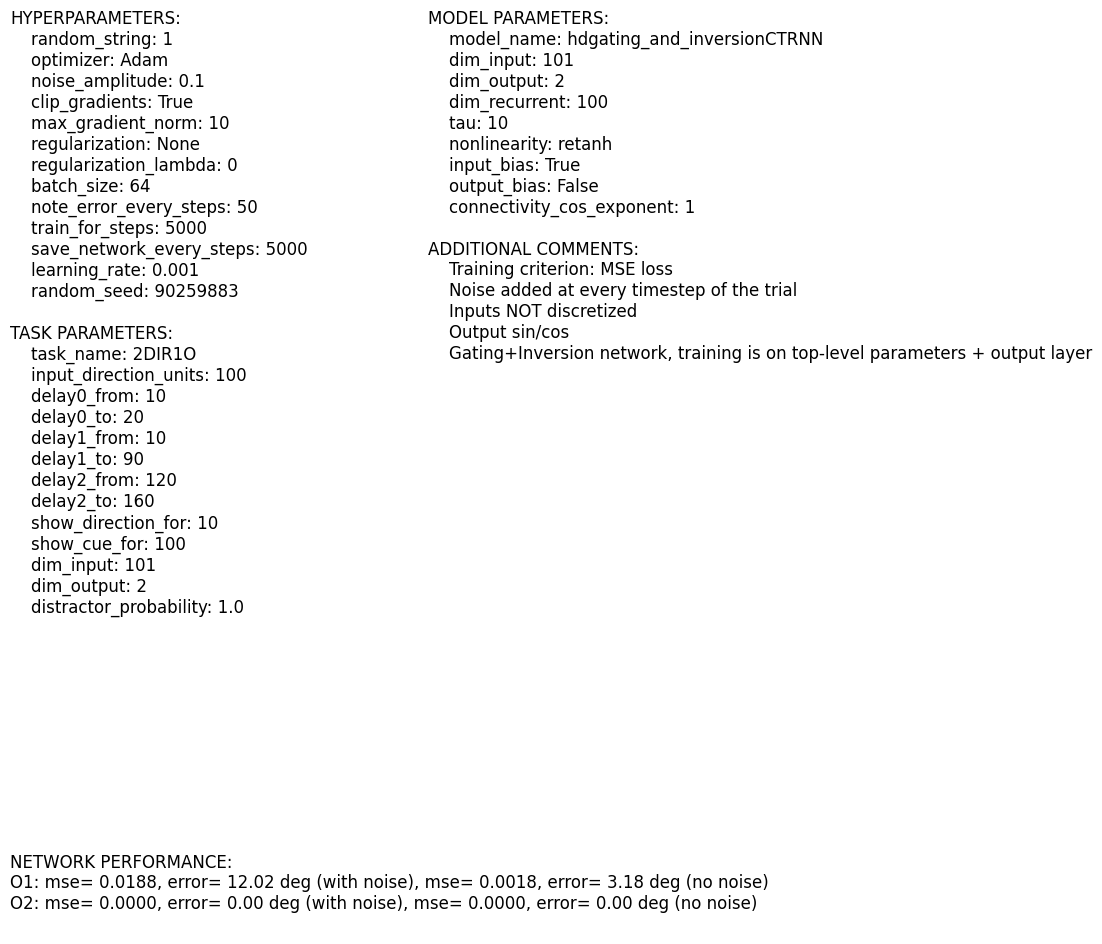

In [2]:
import argparse, json, time, random
import hashlib, torch, math, pathlib
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
from task_and_training import *

with open(f"info.json", 'r', encoding='utf-8') as f:
    j = json.load(f)
hyperparameters = j["hyperparameters"]
task_parameters = j["task_parameters"]
model_parameters = j["model_parameters"]
additional_comments = j["additional_comments"]
directory = j["directory"]
figures_directory="figures/"
pathlib.Path(figures_directory+"a.a").parent.mkdir(parents=True, exist_ok=True)
def save_figure(figure_name):
    plt.savefig(figures_directory+figure_name+".pdf")
    if show_figures: 
        plt.show()
    
# some noise may be necessary to prevent dividing by 0 in some of the analyses
# if noise_amplitude == 0: noise_amplitude = 0.0001

task = Task()
model = Model()
if analyze_network.lower() == "best": network_filename = "model_best.pth"
elif analyze_network.lower() == "final": network_filename = f"model_parameterupdate{hyperparameters['train_for_steps']}.pth"
else: network_filename = f"model_parameterupdate{analyze_network}.pth"
model_state_dict = torch.load(network_filename, map_location=torch.device('cpu'))["model_state_dict"]
model.load_state_dict(model_state_dict)

resolution = 30
ORI_RES = 360//resolution
ORI_SET = torch.arange(0, 360, ORI_RES)
ORI_SET_SIZE = ORI_SET.shape[0]

# fix delays at median values for analysis
delay0, delay1, delay2 = task.get_median_delays()
delay1 = task_parameters["delay1_to"]  # max delay1 (to ensure convergence to final state for analysis)
show_direction_for = task_parameters["show_direction_for"]
show_cue_for = task_parameters["show_cue_for"]
total_time = show_direction_for+show_cue_for+delay0+delay2
t1, t1d = delay0, "before O1 presented"
t1_5, t1_5d = delay0+show_direction_for//2, "amid 01 presentation"
t2, t2d = delay0+show_direction_for, "after O1 presented"
t3, t3d = delay0+show_direction_for+delay1, "before O2 presented"
t3_5, t3_5d = delay0+show_direction_for+delay1+show_direction_for//2, "amid O2 presentation"
t4, t4d = delay0+show_direction_for+delay1+show_direction_for, "after O2 presented"
t5, t5d = delay0+show_direction_for+delay2, "before go cue"
t6, t6d = total_time-1, "at end of task"

# run the model on all possible directions 
ao_input, ao_target, ao_mask = task.make_all_integer_directions_batch(delay0, delay1, delay2, distractor_probability=distractor_probability, resolution=resolution)
ao_noise_mask = task.get_noise_mask(delay0, delay1, delay2)
ao_noise_mask = ao_noise_mask.repeat(ao_input.shape[0], 1).unsqueeze(2).repeat(1, 1, model.dim_recurrent)  # convert to (batch_size, total_time, dim_recurrent)
ao_noise = torch.randn_like(ao_noise_mask) * ao_noise_mask * noise_amplitude
ao_output, ao_h = model.forward(ao_input, noise=ao_noise)

# output model errors (with noise and without)
mse_o1, mse_o2, err_o1, err_o2 = task.calculate_errors(ao_target, ao_output, ao_mask, t5, t6)
ao_output_nn, ao_h_nn = model.forward(ao_input, noise=ao_noise*0)
mse_o1_nn, mse_o2_nn, err_o1_nn, err_o2_nn = task.calculate_errors(ao_target, ao_output_nn, ao_mask, t5, t6)

# for every timestep and every unit, calculate its activity in all trials
ao_data = torch.zeros((total_time, model.dim_recurrent, ORI_SET_SIZE, ORI_SET_SIZE))
for direction1 in range(ORI_SET_SIZE):
    for direction2 in range(ORI_SET_SIZE):
        o = ao_h[direction1 * ORI_SET_SIZE + direction2]
        ao_data[:, :, direction1, direction2] = o
        
# detach from autograd
ao_output = ao_output.detach()
ao_h = ao_h.detach()
ao_data = ao_data.detach()

fig = plt.figure(figsize=(12, 12))
plt.rc('font', **{'family': 'DejaVu Sans', 'weight': 'normal', 'size': 12})
info_string = ""
info_string += "hyperparameters:".upper()
for a, b in hyperparameters.items():
    info_string += f"\n    {a}: {b}"
info_string += "\n\n"
info_string += "task parameters:".upper()
for a, b in task_parameters.items():
    info_string += f"\n    {a}: {b}"
plt.text(0, 1, info_string, bbox=dict(facecolor='red', alpha=0.0), horizontalalignment='left', verticalalignment='top')
info_string = ""
info_string += "model parameters:".upper()
for a, b in model_parameters.items():
    info_string += f"\n    {a}: {b}"
info_string += "\n\n"
info_string += "additional comments:".upper()
for a in additional_comments:
    info_string += f"\n    {a}"
plt.text(0.45, 1, info_string, bbox=dict(facecolor='red', alpha=0.0), horizontalalignment='left', verticalalignment='top')
info_string = ""
info_string += ("Network performance:\n".upper())
info_string += (f"O1: mse= {mse_o1:.4f}, error= {err_o1:.2f} deg (with noise), mse= {mse_o1_nn:.4f}, error= {err_o1_nn:.2f} deg (no noise)\n")
info_string += (f"O2: mse= {mse_o2:.4f}, error= {err_o2:.2f} deg (with noise), mse= {mse_o2_nn:.4f}, error= {err_o2_nn:.2f} deg (no noise)\n")
plt.text(0, 0, info_string, bbox=dict(facecolor='red', alpha=0.0), horizontalalignment='left', verticalalignment='bottom')
plt.axis("off")
save_figure("network_info")

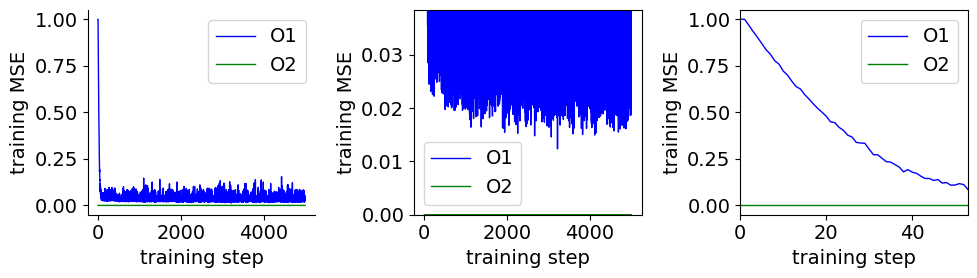

In [3]:
plt.rc('font', **{'family': 'DejaVu Sans', 'weight': 'normal', 'size': 14})
td = torch.load(f"training_dynamics.pt", map_location=torch.device('cpu'))
error_store, error_store_o1, error_store_o2, gradient_norm_store = td[0], td[1], td[2], td[3] 
fig = plt.figure(figsize=(10, 3))
ax = fig.add_subplot(1, 3, 1)
#plt.plot(error_store, "-", linewidth=5, color="k", label="O1+O2")
ax.plot(error_store_o1, "-", linewidth=1, color="b", label="O1")
ax.plot(error_store_o2, "-", linewidth=1, color="g", label="O2")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
#ax.set_ylim(0, 0.3)
ax.set_xlabel("training step")
ax.set_ylabel("training MSE")
ax = fig.add_subplot(1, 3, 2)
#plt.plot(error_store, "-", linewidth=5, color="k", label="O1+O2")
ax.plot(error_store_o1, "-", linewidth=1, color="b", label="O1")
ax.plot(error_store_o2, "-", linewidth=1, color="g", label="O2")
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.legend()
ylim = torch.mean(error_store)
ax.set_ylim(0, ylim)
ax.set_xlabel("training step")
ax.set_ylabel("training MSE")
ax = fig.add_subplot(1, 3, 3)
#plt.plot(error_store, "-", linewidth=3, color="k", label="")
ax.plot(error_store_o1, "-", linewidth=1, color="b", label="O1")
ax.plot(error_store_o2, "-", linewidth=1, color="g", label="O2")
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.legend()
xlim = min(torch.argmax((error_store_o1<0.1).long())*1, hyperparameters["train_for_steps"])
ax.set_xlim(0, xlim)
#ax.set_ylim(0, 0.3)
ax.set_xlabel("training step")
ax.set_ylabel("training MSE")
plt.tight_layout()
save_figure("training_errors")

# Clusters

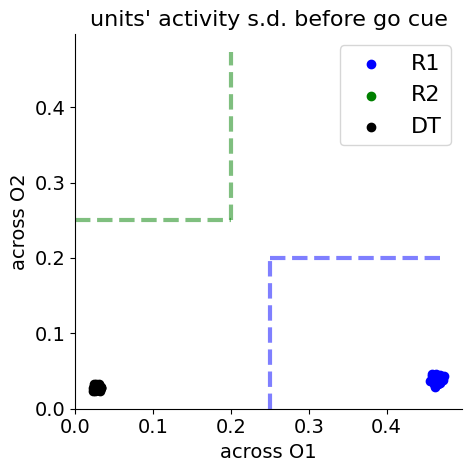

In [4]:
timestep, timestep_description = t5, t5d
cutoff_criterion = "box" # options: ratio, box
ring_cutoff = 2  # if ratio: minumum variance ratio to consider unit a ring unit
min_pri_var = 0.25  # if box: minimum variance in primary direction to consider unit a ring unit
max_sec_var = 0.20  # if box: maximum variance in the other direction to consider unit a ring unit

var_1 = torch.var(torch.mean(ao_data[timestep], dim=2), dim=1)**0.5 + 0.01
var_2 = torch.var(torch.mean(ao_data[timestep], dim=1), dim=1)**0.5 + 0.01


if cutoff_criterion == "ratio":
    R1_i = torch.where(var_1/var_2 > ring_cutoff)[0]
    R2_i = torch.where(var_2/var_1 > ring_cutoff)[0]
    DT_i = torch.tensor([x for x in range(model.dim_recurrent) if (x not in R1_i) and (x not in R2_i)], dtype=int)
elif cutoff_criterion == "box":
    R1_i = torch.where(torch.logical_and(var_1>min_pri_var, var_2<max_sec_var))[0]
    R2_i = torch.where(torch.logical_and(var_2>min_pri_var, var_1<max_sec_var))[0]
    DT_i = torch.tensor([x for x in range(model.dim_recurrent) if (x not in R1_i) and (x not in R2_i)], dtype=int)

mv = max(max(var_1), max(var_2))
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(1, 1, 1)
plt.rc('font', **{'family': 'DejaVu Sans', 'weight': 'normal', 'size': 16})
if cutoff_criterion == "ratio":
    ax.plot([0, mv], [0, mv/ring_cutoff], "--b", linewidth=3, alpha=0.5)
    ax.plot([0, mv/ring_cutoff], [0, mv], "--g", linewidth=3, alpha=0.5)
elif cutoff_criterion == "box":
    ax.plot([min_pri_var, min_pri_var], [0, max_sec_var], "--b", linewidth=3, alpha=0.5)
    ax.plot([min_pri_var, mv], [max_sec_var, max_sec_var], "--b", linewidth=3, alpha=0.5)
    ax.plot([0, max_sec_var], [min_pri_var, min_pri_var], "--g", linewidth=3, alpha=0.5)
    ax.plot([max_sec_var, max_sec_var], [min_pri_var, mv], "--g", linewidth=3, alpha=0.5)
ax.scatter(var_1[R1_i], var_2[R1_i], color="b", label="R1")
ax.scatter(var_1[R2_i], var_2[R2_i], color="g", label="R2")
ax.scatter(var_1[DT_i], var_2[DT_i], color="k", label="DT")
ax.set_xlabel("across O1")
ax.set_ylabel("across O2")
ax.set_title(f"units' activity s.d. {timestep_description}", fontsize=16)
ax.set_xlim(0, mv*1.05)
ax.set_ylim(0, mv*1.05)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.tight_layout()
save_figure("unit_allocations")

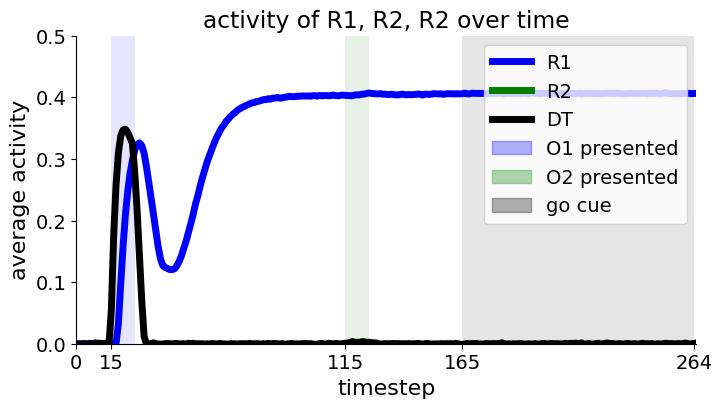

In [5]:
#plt.plot()
time = range(total_time)
plt.rc('font', **{'family': 'DejaVu Sans', 'weight': 'normal', 'size': 14})
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, torch.mean(ao_h[:, :, R1_i], dim=[0, 2]).detach().numpy(), "b-", linewidth=5, markersize=10, label="R1")
ax.plot(time, torch.mean(ao_h[:, :, R2_i], dim=[0, 2]).detach().numpy(), "g-", linewidth=5, markersize=10, label="R2")
ax.plot(time, torch.mean(ao_h[:, :, DT_i], dim=[0, 2]).detach().numpy(), "k-", linewidth=5, markersize=10, label="DT")
ax.set_xlabel('timestep', fontsize=16)
ax.set_ylabel('average activity', fontsize=16)
ax.set_title(f'activity of R1, R2, R2 over time')

ax.set_xticks([0, t1, t3, t5, t6])
# add patches to visualize inputs
ax.axvspan(t1, t2, facecolor="b", alpha=0.1)
ax.axvspan(t3, t4, facecolor="g", alpha=0.1)
ax.axvspan(t5, t6, facecolor="k", alpha=0.1)
# add patches to legend
handles, labels = plt.gca().get_legend_handles_labels()
handles.append(mpatches.Patch(color='b', alpha=0.3, label='O1 presented'))
handles.append(mpatches.Patch(color='g', alpha=0.3, label='O2 presented'))
handles.append(mpatches.Patch(color='k', alpha=0.3, label='go cue'))
ax.legend(handles=handles, loc=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.ylim(0, 0.5)
plt.xlim(0, total_time)
save_figure("cluster_activities")

# Preference changes

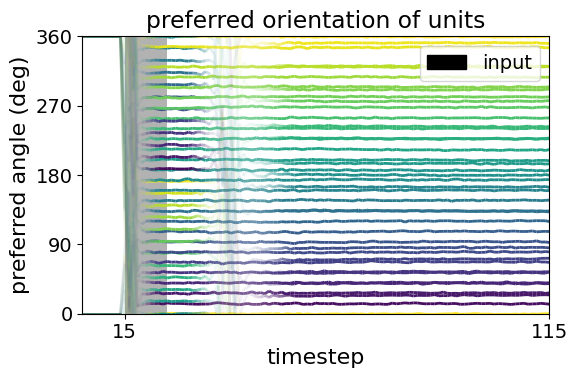

Opacity indicates mean unit activity (across all choices of O1 and O2), squared


In [6]:
alpha_for = "overall_activity"  # what the opacity will indicate the figure. options: overall_activity, tuning_strength

def calc_pref(units_i, timestep=t5, to=1, data=None, round_prefs=False):
    if data is None: data = ao_data
    w = torch.sum(data[timestep][units_i], dim=3-to).detach().numpy()
    a = np.angle(np.sum(w*np.exp(1j*(np.arange(ORI_SET_SIZE)/ORI_SET_SIZE*2*np.pi)).reshape(1, -1), axis=1)/ (np.sum(np.abs(w), axis=1)+0.01)) * 180 / np.pi
    a[a<0] = a[a<0]+360
    a = torch.tensor(a)
    if round_prefs: a = torch.round(a)
    return a
def calc_strength(units_i, timestep=t5, to=1, data=None, minimum_overall_activity_threshold=0.1):
    if data is None: data = ao_data
    w = torch.sum(data[timestep][units_i], dim=3-to).detach().numpy()
    a = np.abs(np.sum(w*np.exp(1j*(np.arange(ORI_SET_SIZE)/ORI_SET_SIZE*2*np.pi)).reshape(1, -1), axis=1)/ (np.sum(np.abs(w), axis=1)+0.01))
    #a = np.abs(np.sum(w*np.exp(1j*(np.arange(ORI_SET_SIZE)/ORI_SET_SIZE*2*np.pi)).reshape(1, -1), axis=1))
    #a[torch.mean(data[timestep][units_i], dim=(1, 2))<minimum_overall_activity_threshold] = 0
    a = torch.tensor(a)
    a *= torch.abs(torch.mean(data[timestep][units_i], dim=(1, 2)))
    return a
prefs_1 = []  # every unit's preferred O1
prefs_2 = []  # every unit's preferred O2
strengths_1 = []  # every unit's preferred O1
strengths_2 = []  # every unit's preferred O2
for timestep in range(total_time):
    prefs_1.append(calc_pref(range(model.dim_recurrent), timestep=timestep, to=1).unsqueeze(0))
    prefs_2.append(calc_pref(range(model.dim_recurrent), timestep=timestep, to=2).unsqueeze(0))
    strengths_1.append(calc_strength(range(model.dim_recurrent), timestep=timestep, to=1).unsqueeze(0))
    strengths_2.append(calc_strength(range(model.dim_recurrent), timestep=timestep, to=2).unsqueeze(0))
prefs_1 = torch.cat(prefs_1)
prefs_2 = torch.cat(prefs_2)
strengths_1 = torch.cat(strengths_1)
strengths_2 = torch.cat(strengths_2)

# sort units according to their preferred directions (don't sort DT)
R1_pref = prefs_1[t5-1][R1_i]
R2_pref = prefs_2[t5-1][R2_i]
DT_pref = prefs_1[t2-1][DT_i]
R1_i = R1_i.clone()[torch.argsort(R1_pref)]
R1_pref = R1_pref.clone()[torch.argsort(R1_pref)]
R2_i = R2_i.clone()[torch.argsort(R2_pref)]
R2_pref = R2_pref.clone()[torch.argsort(R2_pref)]
DT_i = DT_i.clone()[torch.argsort(DT_pref)]
DT_pref = DT_pref.clone()[torch.argsort(DT_pref)]
order_indices = torch.cat((R1_i, DT_i, R2_i))

fig = plt.figure(figsize=(6,4))
time = range(total_time)
ax = fig.add_subplot(1, 1, 1)
indices = np.copy(R1_i)
np.random.shuffle(indices)
for i in indices[::1]:
    if alpha_for == "overall_activity":
        alpha=torch.mean(ao_data[:, i]**2, dim=(1, 2))  # for alpha based on overall mean unit activity
    else:
        alpha=strengths_1[:, i]
    alpha*=5
    alpha[alpha>1] = 1

    # plots the lines corresponding to the preferred directions of units over time
    # deals with preferred directions of units crossing the 0/360 boundary (plots them nicely still)
    raw_preferences = prefs_1[:, i]
    raw_preferences[:t1] = 0
    d_preferences = raw_preferences[1:] - raw_preferences[:-1]
    d_preferences[d_preferences<-100] += 360
    d_preferences[d_preferences>100] -= 360
    new_preferences = torch.ones(raw_preferences.shape) * raw_preferences[0]
    new_preferences[1:] += torch.cumsum(d_preferences, 0)
    for diff in [-720, -360, 0, 360, 720]:
        points = np.vstack((time, new_preferences+diff)).T.reshape(-1, 1, 2)
        segments = np.hstack((points[:-1], points[1:]))
        lc = LineCollection(segments, alpha=alpha, color=plt.cm.viridis(prefs_1[-1, i].item()/360), lw=2)
        line = ax.add_collection(lc)
ax.set_xlabel('timestep', fontsize=16)
ax.set_ylabel('preferred angle (deg)', fontsize=16)
ax.set_title("preferred orientation of units")
t_to = t3 # (t1+t3)//2
ax.set_xticks([0, t1, t_to])
ax.set_yticks([0, 90, 180, 270, 360])
ax.set_xlim(t1-10, t_to)
ax.set_ylim(0, 360)
# add patches to visualize inputs
ax.axvspan(t1, t2, facecolor="k", alpha=0.3)
handles, labels = plt.gca().get_legend_handles_labels()
handles.append(mpatches.Patch(color='k', alpha=1.0, label='input'))
ax.legend(handles=handles, loc=1)
plt.tight_layout()
save_figure("preference_change_lines_simple")
if alpha_for == "overall_activity":
    print("Opacity indicates mean unit activity (across all choices of O1 and O2), squared")
else: 
    print("Opacity indicates strength of tuning to direction")

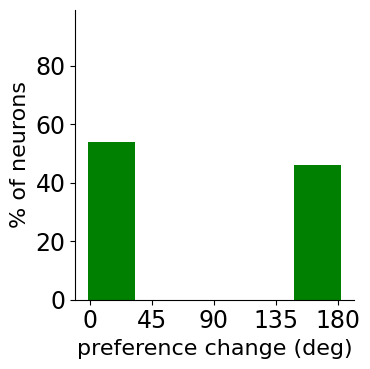

In [7]:
def calc_pref_ave(units_i, timestep_from, timestep_to, to=1, data=None, round_prefs=False):
    if data is None: data = ao_data
    w = torch.sum(data[timestep_from:timestep_to][:, units_i], dim=(0, 4-to)).detach().numpy()
    a = np.angle(np.sum(w*np.exp(1j*(np.arange(ORI_SET_SIZE)/ORI_SET_SIZE*2*np.pi)).reshape(1, -1), axis=1)/ (np.sum(np.abs(w), axis=1)+0.01)) * 180 / np.pi
    a[a<0] = a[a<0]+360
    a = torch.tensor(a)
    if round_prefs: a = torch.round(a)
    return a
# UNSTRETCHED
fig = plt.figure(figsize=(4, 4))
plt.rc('font', **{'family': 'DejaVu Sans', 'weight': 'normal', 'size': 17})
ylim = 99
ax = fig.add_subplot(1, 1, 1)
bins = 5
units_i = R1_i
cue_from, cue_to = t1, t2
delay_from, delay_to = t2+20, t3
prefc = calc_pref_ave(units_i, cue_from, cue_to, to=1)-calc_pref_ave(units_i, delay_from, delay_to, to=1)
prefc[prefc<-180] = prefc[prefc<-180]+360
prefc[prefc>180] = prefc[prefc>180]-360
prefc = torch.abs(prefc)
hist = torch.histc(prefc, bins = bins, min = 0, max = 180)
hist /= torch.sum(hist)
x = torch.arange(bins)/bins * 180
ax.bar(x*1.033+16, hist*100, align='center', width=180/bins/1.05, color="green")
#ax.set_title("O1 tuning, R1 units, first delay", fontsize=16)
ax.set_xlabel('preference change (deg)', fontsize=16)
ax.set_ylabel('% of neurons', fontsize=16)
ax.set_xticks(torch.arange(0, 181, 45))
ax.set_ylim(0, ylim)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig("ccn_changepref_1.pdf", bbox_inches = 'tight')

## Intertrial correlations: Fixation period

In [9]:
batch_size = 1000
a_angles = [0, 90, 180, 270] # [0, 45, 90, 135, 180, 225, 270, 315]
b = 0
noise_multiplier = 5

inputs = []
input_directions = []
for a in a_angles:
    trial_input = task._make_trial(a, b, delay0, delay1, delay2)[0].repeat(batch_size, 1, 1)
    input_directions.append([a] * batch_size)
    inputs.append(trial_input)
o1_a_o2_b_input = torch.cat(inputs, dim=0)
input_directions = torch.tensor(input_directions)

nm = task.get_noise_mask(delay0, delay1, delay2)
nm = nm.repeat(len(a_angles)*batch_size, 1).unsqueeze(2).repeat(1, 1, model.dim_recurrent)
nm = torch.randn_like(nm) * nm * noise_amplitude
nm[:, :] *= noise_multiplier


o1_a_o2_b_output, o1_a_o2_b_h = model.forward(o1_a_o2_b_input, noise=nm)
print(o1_a_o2_b_h.shape)

torch.Size([4000, 265, 100])


In [10]:

allow_peaks_angle = 7.5

t_from = t2+20
t_to = t3 # second delay to match experimental data

# uncomment this to run the code for the correlation in the fixation period
t_from, t_to = 0, t1

stim_direction_array = []
noise_correlation_array = []
pref_dir_diff_array = []

for i in R1_i:
    for j in R1_i:
        if i <= j: continue
        i_pref_dir = R1_pref[i]
        j_pref_dir = R1_pref[j]

        pref_angle_distance = np.abs(i_pref_dir-j_pref_dir).item()
        if pref_angle_distance > 180: pref_angle_distance = 360 - pref_angle_distance

        #print(f"i: {i}, j: {j}, i_pref_dir: {i_pref_dir}, j_pref_dir: {j_pref_dir}")
        
        for angle_i, angle in enumerate(a_angles):
            # The code below checks which cluster the pair of units and stimulus direction fall into:
            # -1: Peaks
            # 0: Out-Flanks
            # 1: In-Flank
            # Normalize angles to -180 to +180 range
            pref_dir1_norm = ((i_pref_dir + 180) % 360) - 180
            pref_dir2_norm = ((j_pref_dir + 180) % 360) - 180
            stim_dir_norm = ((angle + 180) % 360) - 180
            # Sort the pref directions to have pref_dir1 < pref_dir2
            if pref_dir1_norm > pref_dir2_norm:
                pref_dir1_norm, pref_dir2_norm = pref_dir2_norm, pref_dir1_norm
            # Check if stim direction is between pref directions
            is_between_code = 0
            if min(abs(stim_dir_norm - pref_dir1_norm), abs(stim_dir_norm - pref_dir2_norm)) <= allow_peaks_angle or \
               min(abs(stim_dir_norm - pref_dir1_norm + 360), abs(stim_dir_norm - pref_dir1_norm - 360)) <= allow_peaks_angle or \
               min(abs(stim_dir_norm - pref_dir2_norm + 360), abs(stim_dir_norm - pref_dir2_norm - 360)) <= allow_peaks_angle:
                is_between_code = -1
            elif pref_dir2_norm - pref_dir1_norm <= 180:
                # Normal case - no wrapping around ±180
                is_between_code = int(pref_dir1_norm <= stim_dir_norm <= pref_dir2_norm)
            else:
                # Case where preferred directions wrap around ±180
                # e.g. pref1 = 170, pref2 = -160
                # Then "between" means stim >= pref1 OR stim <= pref2
                is_between_code = int(stim_dir_norm >= pref_dir1_norm or stim_dir_norm <= pref_dir2_norm)

            batch_i_start = angle_i * batch_size
            batch_i_end = batch_i_start + batch_size
            mean_fr_i = o1_a_o2_b_h[batch_i_start:batch_i_end, t_from:t_to, i].mean(dim=1).detach().numpy()
            mean_fr_j = o1_a_o2_b_h[batch_i_start:batch_i_end, t_from:t_to, j].mean(dim=1).detach().numpy()
            corr_i_j = np.corrcoef(mean_fr_i, mean_fr_j)[0, 1]

            #print(f"stim dir: {stim_dir_norm}, i_dir: {pref_dir1_norm}, j_dir: {pref_dir2_norm}, is_between_code: {is_between_code}, corr: {corr_i_j}")
            pref_dir_diff_array.append(pref_angle_distance)

            stim_direction_array.append(is_between_code)
            noise_correlation_array.append(corr_i_j)

C:\Users\Andrii\AppData\Local\Temp\ipykernel_24240\3713032719.py:19: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  pref_angle_distance = np.abs(i_pref_dir-j_pref_dir).item()


P-values (two-sided t-test against 0):
In-Flank: p=1.090e-03
Peaks: p=1.019e-06
Out-Flanks: p=4.175e-54


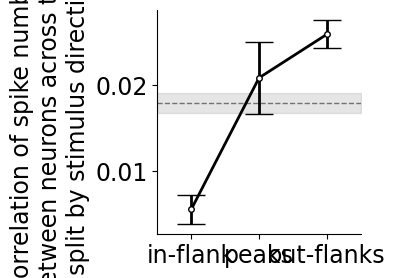

In [11]:
import scipy.stats as stats

# Convert lists to numpy arrays for easier manipulation
stim_direction_array_fixation = np.array(stim_direction_array)
noise_correlation_array_fixation = np.array(noise_correlation_array)

# Calculate means and SEMs for each group
between_corrs_fixation = noise_correlation_array_fixation[stim_direction_array_fixation==1]
peaks_corrs_fixation = noise_correlation_array_fixation[stim_direction_array_fixation==-1]
not_between_corrs_fixation = noise_correlation_array_fixation[stim_direction_array_fixation==0]

means_fixation = [np.mean(between_corrs_fixation), np.mean(peaks_corrs_fixation), np.mean(not_between_corrs_fixation)]
sems_fixation = [stats.sem(between_corrs_fixation), stats.sem(peaks_corrs_fixation), stats.sem(not_between_corrs_fixation)]

# Calculate overall mean and SEM
overall_mean_fixation = np.mean(noise_correlation_array_fixation)
overall_sem_fixation = stats.sem(noise_correlation_array_fixation)

# Calculate p-values using two-sided t-test against 0
p_values_fixation = [stats.ttest_1samp(between_corrs_fixation, 0, alternative='two-sided').pvalue,
            stats.ttest_1samp(peaks_corrs_fixation, 0, alternative='two-sided').pvalue,
            stats.ttest_1samp(not_between_corrs_fixation, 0, alternative='two-sided').pvalue]

print("P-values (two-sided t-test against 0):")
print(f"In-Flank: p={p_values_fixation[0]:.3e}")
print(f"Peaks: p={p_values_fixation[1]:.3e}")  
print(f"Out-Flanks: p={p_values_fixation[2]:.3e}")

# Create the plot
fig, ax = plt.subplots(figsize=(4, 3))
plt.rc('font', **{'family': 'Arial', 'weight': 'normal', 'size': 14})
x = np.arange(3)

# Plot individual points with jitter
jitter = np.random.normal(0, 0.07, len(noise_correlation_array_fixation))
#plt.ylim(-0.1, 0.3)
plt.xlim(-0.5, 2.5)

# Add horizontal line and shaded region for overall mean and SEM
ax.axhline(y=overall_mean_fixation, color='black', linestyle='--', alpha=.5, linewidth=1)
ax.fill_between([-0.5, 2.5], 
                overall_mean_fixation - overall_sem_fixation,
                overall_mean_fixation + overall_sem_fixation,
                color='gray', alpha=0.2)

# Plot line with error bars
ax.errorbar(x, means_fixation, yerr=sems_fixation, capsize=10, color='black', marker='.', markersize=8,
           markerfacecolor='white', markeredgecolor='black', linewidth=2)

# Customize the plot
ax.set_xticks(x)
ax.set_xticklabels(['in-flank', 'peaks', 'out-flanks'])
ax.set_ylabel('correlation of spike numbers\nbetween neurons across trials\n(split by stimulus direction)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../../paper_figures/g_i_t_noise_correlation_between_flank_and_peaks_fixation.pdf', bbox_inches='tight')


In [12]:
t_from = t2+20
t_to = t3 # second delay to match experimental data

# uncomment this to run the code for the correlation in the fixation period
#t_from, t_to = 0, t1

stim_direction_array = []
noise_correlation_array = []
pref_dir_diff_array = []

for i in R1_i:
    for j in R1_i:
        if i <= j: continue
        i_pref_dir = R1_pref[i]
        j_pref_dir = R1_pref[j]

        pref_angle_distance = np.abs(i_pref_dir-j_pref_dir).item()
        if pref_angle_distance > 180: pref_angle_distance = 360 - pref_angle_distance

        #print(f"i: {i}, j: {j}, i_pref_dir: {i_pref_dir}, j_pref_dir: {j_pref_dir}")
        
        for angle_i, angle in enumerate(a_angles):
            # The code below checks which cluster the pair of units and stimulus direction fall into:
            # -1: Peaks
            # 0: Out-Flanks
            # 1: In-Flank
            # Normalize angles to -180 to +180 range
            pref_dir1_norm = ((i_pref_dir + 180) % 360) - 180
            pref_dir2_norm = ((j_pref_dir + 180) % 360) - 180
            stim_dir_norm = ((angle + 180) % 360) - 180
            # Sort the pref directions to have pref_dir1 < pref_dir2
            if pref_dir1_norm > pref_dir2_norm:
                pref_dir1_norm, pref_dir2_norm = pref_dir2_norm, pref_dir1_norm
            # Check if stim direction is between pref directions
            is_between_code = 0
            if min(abs(stim_dir_norm - pref_dir1_norm), abs(stim_dir_norm - pref_dir2_norm)) <= allow_peaks_angle or \
               min(abs(stim_dir_norm - pref_dir1_norm + 360), abs(stim_dir_norm - pref_dir1_norm - 360)) <= allow_peaks_angle or \
               min(abs(stim_dir_norm - pref_dir2_norm + 360), abs(stim_dir_norm - pref_dir2_norm - 360)) <= allow_peaks_angle:
                is_between_code = -1
            elif pref_dir2_norm - pref_dir1_norm <= 180:
                # Normal case - no wrapping around ±180
                is_between_code = int(pref_dir1_norm <= stim_dir_norm <= pref_dir2_norm)
            else:
                # Case where preferred directions wrap around ±180
                # e.g. pref1 = 170, pref2 = -160
                # Then "between" means stim >= pref1 OR stim <= pref2
                is_between_code = int(stim_dir_norm >= pref_dir1_norm or stim_dir_norm <= pref_dir2_norm)

            batch_i_start = angle_i * batch_size
            batch_i_end = batch_i_start + batch_size
            mean_fr_i = o1_a_o2_b_h[batch_i_start:batch_i_end, t_from:t_to, i].mean(dim=1).detach().numpy()
            mean_fr_j = o1_a_o2_b_h[batch_i_start:batch_i_end, t_from:t_to, j].mean(dim=1).detach().numpy()
            corr_i_j = np.corrcoef(mean_fr_i, mean_fr_j)[0, 1]

            #print(f"stim dir: {stim_dir_norm}, i_dir: {pref_dir1_norm}, j_dir: {pref_dir2_norm}, is_between_code: {is_between_code}, corr: {corr_i_j}")
            pref_dir_diff_array.append(pref_angle_distance)

            stim_direction_array.append(is_between_code)
            noise_correlation_array.append(corr_i_j)

C:\Users\Andrii\AppData\Local\Temp\ipykernel_24240\2781710920.py:17: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  pref_angle_distance = np.abs(i_pref_dir-j_pref_dir).item()


P-values (two-sided tests against 0):
In-Flank: t-test p=6.540e-03, U-test p=2.075e-11
Peaks: t-test p=4.770e-01, U-test p=4.645e-01
Out-Flanks: t-test p=2.659e-11, U-test p=1.938e-03

P-values (compared to fixation mean):
In-Flank vs fixation: t-test p=1.868e-05, U-test p=5.249e-17 -- one sided
Peaks vs fixation: t-test p=9.477e-01, U-test p=2.064e-01 -- two sided
Out-Flanks vs fixation: t-test p=3.404e-07, U-test p=6.212e-02 -- one sided

P-values between groups:
In-Flank vs Peaks: t-test p=3.675e-02, U-test p=4.573e-02 -- one sided
Peaks vs Out-Flanks: t-test p=4.456e-02, U-test p=4.172e-02 -- one sided
In-Flank vs Out-Flanks: t-test p=1.180e-10, U-test p=1.837e-10 -- one sided


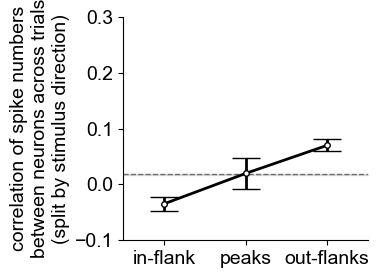

In [13]:
import scipy.stats as stats

# Convert lists to numpy arrays for easier manipulation
stim_direction_array = np.array(stim_direction_array)
noise_correlation_array = np.array(noise_correlation_array)

# Calculate means and SEMs for each group
between_corrs = noise_correlation_array[stim_direction_array==1]
peaks_corrs = noise_correlation_array[stim_direction_array==-1]
not_between_corrs = noise_correlation_array[stim_direction_array==0]

means = [np.mean(between_corrs), np.mean(peaks_corrs), np.mean(not_between_corrs)]
sems = [stats.sem(between_corrs), stats.sem(peaks_corrs), stats.sem(not_between_corrs)]

# Calculate p-values using two-sided t-test and Mann-Whitney U test against 0
p_values_zero_t = [stats.ttest_1samp(between_corrs, 0, alternative='two-sided').pvalue,
                   stats.ttest_1samp(peaks_corrs, 0, alternative='two-sided').pvalue,
                   stats.ttest_1samp(not_between_corrs, 0, alternative='two-sided').pvalue]

p_values_zero_u = [stats.mannwhitneyu(between_corrs, np.zeros_like(between_corrs), alternative='two-sided').pvalue,
                   stats.mannwhitneyu(peaks_corrs, np.zeros_like(peaks_corrs), alternative='two-sided').pvalue,
                   stats.mannwhitneyu(not_between_corrs, np.zeros_like(not_between_corrs), alternative='two-sided').pvalue]

print("P-values (two-sided tests against 0):")
print(f"In-Flank: t-test p={p_values_zero_t[0]:.3e}, U-test p={p_values_zero_u[0]:.3e}")
print(f"Peaks: t-test p={p_values_zero_t[1]:.3e}, U-test p={p_values_zero_u[1]:.3e}")
print(f"Out-Flanks: t-test p={p_values_zero_t[2]:.3e}, U-test p={p_values_zero_u[2]:.3e}")

# Calculate p-values comparing groups to fixation mean using t-test and Mann-Whitney U test
p_values_fix_t = [stats.ttest_1samp(between_corrs, overall_mean_fixation, alternative='less').pvalue,
                  stats.ttest_1samp(peaks_corrs, overall_mean_fixation, alternative='two-sided').pvalue,
                  stats.ttest_1samp(not_between_corrs, overall_mean_fixation, alternative='greater').pvalue]

p_values_fix_u = [stats.mannwhitneyu(between_corrs, np.full_like(between_corrs, overall_mean_fixation), alternative='less').pvalue,
                  stats.mannwhitneyu(peaks_corrs, np.full_like(peaks_corrs, overall_mean_fixation), alternative='two-sided').pvalue,
                  stats.mannwhitneyu(not_between_corrs, np.full_like(not_between_corrs, overall_mean_fixation), alternative='greater').pvalue]

print("\nP-values (compared to fixation mean):")
print(f"In-Flank vs fixation: t-test p={p_values_fix_t[0]:.3e}, U-test p={p_values_fix_u[0]:.3e} -- one sided")
print(f"Peaks vs fixation: t-test p={p_values_fix_t[1]:.3e}, U-test p={p_values_fix_u[1]:.3e} -- two sided")
print(f"Out-Flanks vs fixation: t-test p={p_values_fix_t[2]:.3e}, U-test p={p_values_fix_u[2]:.3e} -- one sided")

# Calculate p-values between groups using t-test and Mann-Whitney U test
p_value_in_vs_peaks_t = stats.ttest_ind(between_corrs, peaks_corrs, alternative='less').pvalue
p_value_peaks_vs_out_t = stats.ttest_ind(peaks_corrs, not_between_corrs, alternative='less').pvalue
p_value_in_vs_out_t = stats.ttest_ind(between_corrs, not_between_corrs, alternative='less').pvalue

p_value_in_vs_peaks_u = stats.mannwhitneyu(between_corrs, peaks_corrs, alternative='less').pvalue
p_value_peaks_vs_out_u = stats.mannwhitneyu(peaks_corrs, not_between_corrs, alternative='less').pvalue
p_value_in_vs_out_u = stats.mannwhitneyu(between_corrs, not_between_corrs, alternative='less').pvalue

print("\nP-values between groups:")
print(f"In-Flank vs Peaks: t-test p={p_value_in_vs_peaks_t:.3e}, U-test p={p_value_in_vs_peaks_u:.3e} -- one sided")
print(f"Peaks vs Out-Flanks: t-test p={p_value_peaks_vs_out_t:.3e}, U-test p={p_value_peaks_vs_out_u:.3e} -- one sided")
print(f"In-Flank vs Out-Flanks: t-test p={p_value_in_vs_out_t:.3e}, U-test p={p_value_in_vs_out_u:.3e} -- one sided")

# Create the plot
fig, ax = plt.subplots(figsize=(4, 3))
plt.rc('font', **{'family': 'Arial', 'weight': 'normal', 'size': 14})
x = np.arange(3)

# Plot individual points with jitter
jitter = np.random.normal(0, 0.07, len(noise_correlation_array))
plt.xlim(-0.5, 2.5)
plt.ylim(-0.1, 0.3)

# Add horizontal line and shaded region for fixation mean ± SEM
ax.axhline(y=overall_mean_fixation, color='black', linestyle='--', alpha=.5, linewidth=1)
ax.fill_between([-0.5, 2.5], 
                overall_mean_fixation - overall_sem_fixation,
                overall_mean_fixation + overall_sem_fixation,
                color='gray', alpha=0.2)

# Plot line with error bars
ax.errorbar(x, means, yerr=sems, capsize=10, color='black', marker='.', markersize=8,
           markerfacecolor='white', markeredgecolor='black', linewidth=2)

# Customize the plot
ax.set_xticks(x)
ax.set_xticklabels(['in-flank', 'peaks', 'out-flanks'])
ax.set_ylabel('correlation of spike numbers\nbetween neurons across trials\n(split by stimulus direction)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../../paper_figures/g_i_t_noise_correlation_between_flank_and_peaks.pdf', bbox_inches='tight')
